# Hit Tuning studies

We're using the latest version of `icaruscode`, `v10_06_00_06p03` with all the features included from the work Matteo Vicenzi has been doing on the PMT-overlay and some of the fixes introduced by Micheal Carrigan on the Hit Finder settings



In [92]:
import uproot
import mplhep as hep

# import ultraplot as plot
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import xarray as xr

from os import path

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D

import sqlite3 as sql
import corner

import ROOT
from galleryUtils import loadConfiguration

sns.reset_orig()

# Utilities 

I have some points that are not present (`lar` did segfault for some reason on them). The idea is to get the list of files and from them retrieve back the configurations. 

In [5]:
missing_bnb = np.loadtxt('notebooks/missingBnb.log')
missing_nue = np.loadtxt('notebooks/missingNue.log')

In [6]:
from dataclasses import dataclass
from datetime import datetime
from typing import Literal, List, Dict, Any

@dataclass
class ParamSpec:
    name: str
    low: float
    high: float
    kind: Literal['float', 'int']
    size: int = 1
    decimals: int = 2
    fcl_paths: List[str] = None
    is_per_plane: bool = False

    def sample(self, x: float):
        '''
        Sample a value given a normalized x in [0,1].
        For ints, ensures uniform discrete coverage instead of rounding.
        '''
        if self.kind == 'int':
            n_bins = int(self.high - self.low + 1)
            idx = int(x * n_bins)   # map x to integer bin
            idx = min(idx, n_bins - 1)  # handle x==1 edge
            val = self.low + idx
        else:
            val = self.low + x * (self.high - self.low)
            val = round(val, self.decimals)

        if self.size == 1:
            return val
        return [val] * self.size

@dataclass
class ResultSpec:
    name: str
    dtype: Literal['REAL', 'INTEGER'] = 'REAL'   # or INTEGER

class ParamSet:
    def __init__(self, values: Dict[str, Any]):
        self.values = values

    def to_flat_dict(self):
        flat = {}
        for k, v in self.values.items():
            if isinstance(v, list):
                for i, val in enumerate(v):
                    flat[f'{k}_{i}'] = val
            else:
                flat[k] = v
        return flat

    def __str__(self):
        lines = ["ParamSet:"]
        for k, v in self.values.items():
            if isinstance(v, list):
                vals = ", ".join(str(x) for x in v)
                lines.append(f"  {k}: [{vals}]")
            else:
                lines.append(f"  {k}: {v}")
        return "\n".join(lines)
    
class FclManager:

    def __init__(self, template_path: str):
        with open(template_path) as f:
            self.template = f.read()

    def generate(self, params: ParamSet, specs: Dict[str, ParamSpec], output_path: str, tag: str):
        text = self.template

        text+='\n# ---\n# Custom configuration settings below (tag: {tag})\n# ---\n\n'.format(tag=tag)

        for name, value in params.values.items():
            spec = specs[name]

            for path in spec.fcl_paths:
                if spec.is_per_plane:
                    for i in range(spec.size):
                        full_path = path.format(plane=i)
                        text = self._set_value(text, full_path, value[i])
                else:
                    text = self._set_value(text, path, value)

        with open(output_path, 'w') as f:
            f.write(text)

    def _set_value(self, text, key, value):
        val_str = f'[{", ".join(map(str, value))}]' if isinstance(value, list) else str(value)
        pattern = rf'({re.escape(key)}\s*:\s*)([^\n#]+)'

        if re.search(pattern, text):
            return re.sub(pattern, rf'\1{val_str}', text)
        else:
            return text + f'{key}: {val_str}\n'

    def parse(self, fcl_path: str, specs: Dict[str, ParamSpec]) -> ParamSet:

        configuration = loadConfiguration(fcl_path)

        values = {}

        for name, spec in specs.items():
            if spec.is_per_plane:
                vals = []
                for i in range(spec.size):
                    full_path = spec.fcl_paths[0].format(plane=i)
                    if not configuration.has_key(full_path):
                        print(f'[FCL MANAGER WARNING CRITICAL] Missing key {name} value, this will be assigned a null value -1')
                        vals.append(-1)
                    else:
                        match = configuration.get[spec.kind](full_path)
                        # print(f'[FCL MANAGER DEBUG] For {name} found {match}')
                        vals.append(match)
                values[name] = vals
            else:
                # is either a singleton (size==1) or a tuple
                if spec.size == 1:
                    if not configuration.has_key(spec.fcl_paths[0]):
                        print(f'[FCL MANAGER WARNING CRITICAL] Missing key {name} value, this will be assigned a null value -1')
                        values[name] = -1
                    else:
                        values[name] = configuration.get[spec.kind](spec.fcl_paths[0])
                        # print(f'[FCL MANAGER DEBUG] For {name} found {match}')
                else:
                    if not configuration.has_key(spec.fcl_paths[0]):
                        print(f'[FCL MANAGER WARNING CRITICAL] Missing key {name} value, this will be assigned a null value -1')
                        values[name] = [-1] * spec.size
                    else:
                        values[name] = list(configuration.get[f'std::vector<{spec.kind}>'](spec.fcl_paths[0]))
                        # print(f'[FCL MANAGER DEBUG] For {name} found {match}')

        parameter_set = ParamSet(values)
        print(parameter_set)
        return parameter_set

Using the same Parameter spec as the one used for the grid search, so the manager is working properly

In [7]:
def build_specs():

    producers = [
        'gaushit2dTPCEE',
        'gaushit2dTPCEW',
        'gaushit2dTPCWE',
        'gaushit2dTPCWW'
    ]

    def p(path):
        return [f'physics.producers.{prod}.{path}' for prod in producers]

    return {
        'roiThreshold': ParamSpec(
            'roiThreshold', 3, 7, 'float', size=3,
            is_per_plane=True,
            fcl_paths=p('HitFinderToolVec.CandidateHitsPlane{plane}.RoiThreshold')
        ),
        
        'nextADCThreshold': ParamSpec(
            'nextADCThreshold', -0.3, 0, 'float', size=3,
            is_per_plane=True,
            fcl_paths=p('HitFinderToolVec.CandidateHitsPlane{plane}.NextADCThreshold')
        ),

        'maxMultiHit': ParamSpec(
            'maxMultiHit', 5, 10, 'int', 
            fcl_paths=p('MaxMultiHit')
        ),

        'chi2NDF': ParamSpec(
            'chi2NDF', 200, 2500, 'float',
            fcl_paths=p('Chi2NDF')
        ),

        'longMaxHits': ParamSpec(
            'longMaxHits', 5, 15, 'int', size=3, 
            fcl_paths=p('LongMaxHits')
        ),

        'longPulseWidth': ParamSpec(
            'longPulseWidth', 8, 18, 'int', size=3, 
            fcl_paths=p('LongPulseWidth')
        ),
    }

In [8]:
specs = build_specs()
fcl_manager = FclManager('fcl/lhsBase.fcl')

In [11]:
WHERE_TO_FIND_FHICL = path.join(
    '/exp/icarus/app/users/msotgia',
    'devareas/dev_v10_06_00_06p03_twoDValidations/localProducts_icaruscode_v10_06_00_06p03_e26_prof',
    'gridFcl'
)

'/exp/icarus/app/users/msotgia/devareas/dev_v10_06_00_06p03_twoDValidations/localProducts_icaruscode_v10_06_00_06p03_e26_prof/gridFcl'

In [21]:
import glob

missing_bnb_dicts = []
missing_nue_dicts = []

for missing in missing_bnb:
    missing_bnb_dicts.append(fcl_manager.parse(glob.glob(path.join(WHERE_TO_FIND_FHICL, f'*_{missing:.0f}*fcl'))[-1], specs=specs).to_flat_dict())

for missing in missing_nue:
    missing_nue_dicts.append(fcl_manager.parse(glob.glob(path.join(WHERE_TO_FIND_FHICL, f'*_{missing:.0f}*fcl'))[-1], specs=specs).to_flat_dict())

missing_bnb_points = pd.DataFrame(missing_bnb_dicts)
missing_nue_points = pd.DataFrame(missing_nue_dicts)

ParamSet:
  roiThreshold: [3.799999952316284, 3.799999952316284, 3.799999952316284]
  nextADCThreshold: [-0.27000001072883606, -0.27000001072883606, -0.27000001072883606]
  maxMultiHit: 6
  chi2NDF: 2271.2900390625
  longMaxHits: [12, 12, 12]
  longPulseWidth: [9, 9, 9]
ParamSet:
  roiThreshold: [4.119999885559082, 4.119999885559082, 4.119999885559082]
  nextADCThreshold: [-0.11999999731779099, -0.11999999731779099, -0.11999999731779099]
  maxMultiHit: 10
  chi2NDF: 2326.89990234375
  longMaxHits: [11, 11, 11]
  longPulseWidth: [16, 16, 16]
ParamSet:
  roiThreshold: [5.880000114440918, 5.880000114440918, 5.880000114440918]
  nextADCThreshold: [-0.20000000298023224, -0.20000000298023224, -0.20000000298023224]
  maxMultiHit: 10
  chi2NDF: 1259.5
  longMaxHits: [13, 13, 13]
  longPulseWidth: [11, 11, 11]
ParamSet:
  roiThreshold: [4.199999809265137, 4.199999809265137, 4.199999809265137]
  nextADCThreshold: [-0.23999999463558197, -0.23999999463558197, -0.23999999463558197]
  maxMultiHit: 9

In [24]:
missing_bnb_points.head()

,roiThreshold_0,roiThreshold_1,roiThreshold_2,nextADCThreshold_0,nextADCThreshold_1,nextADCThreshold_2,maxMultiHit,chi2NDF,longMaxHits_0,longMaxHits_1,longMaxHits_2,longPulseWidth_0,longPulseWidth_1,longPulseWidth_2
0,3.80,3.80,3.80,-0.27,-0.27,-0.27,6,2271.290039,12,12,12,9,9,9
1,4.12,4.12,4.12,-0.12,-0.12,-0.12,10,2326.899902,11,11,11,16,16,16
2,5.88,5.88,5.88,-0.20,-0.20,-0.20,10,1259.500000,13,13,13,11,11,11
3,4.20,4.20,4.20,-0.24,-0.24,-0.24,9,529.010010,13,13,13,15,15,15
4,5.14,5.14,5.14,-0.29,-0.29,-0.29,9,759.070007,9,9,9,12,12,12


In [25]:
missing_bnb_points.keys()

Index(['roiThreshold_0', 'roiThreshold_1', 'roiThreshold_2',
       'nextADCThreshold_0', 'nextADCThreshold_1', 'nextADCThreshold_2',
       'maxMultiHit', 'chi2NDF', 'longMaxHits_0', 'longMaxHits_1',
       'longMaxHits_2', 'longPulseWidth_0', 'longPulseWidth_1',
       'longPulseWidth_2'],
      dtype='object')

# Definining the plot of the full grid of parameters


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_corner(data, missing_data, plane, tag):
    # Format column names
    base_cols = {
        f'roiThreshold_{plane}': 'RoiThreshold', 
        f'nextADCThreshold_{plane}': 'NextADCThreshold', 
        'maxMultiHit': 'MaxMultiHit', 
        'chi2NDF': 'Chi2NDF', 
        f'longMaxHits_{plane}': 'LongMaxHits', 
        f'longPulseWidth_{plane}': 'LongPulseWidth'
    }
    
    formatted_vars = [c.format(plane=plane) for c in base_cols.keys()]
    ratio_col = f'ratioPerJobPlane{plane}'

    g = sns.PairGrid(data, vars=formatted_vars, corner=True)

    # 1. INVERTED SEPARATION (Closest to 1.0 = Biggest)
    # Calculate absolute distance from 1.0
    dist = (data[ratio_col] - 1.0).abs()
    
    # Width: smaller = sharper focus on 1.0
    width = 0.05
    # Gaussian formula: exp(-(dist^2) / (2 * width^2))
    bg_sizes = np.exp(-(dist**2) / (2 * width**2)) * 300 + 10

    # 2. MAP BACKGROUND (LHS)
    # Using RdYlGn_r: Below 1 = Greenish, Above 1 = Reddish
    # vmin/vmax set to 0.8/1.2 centers the "Green-Red" transition at 1.0
    g.map_offdiag(
        sns.scatterplot, 
        # alpha=0.4, 
        s=bg_sizes, 
        c=data[ratio_col], 
        cmap='Greens', 
        vmin=data[ratio_col].min(), 
        vmax=data[ratio_col].max(),
        # edgecolor='none'
    )

    # 3. LAYER MISSING DATA (BLUE 'x')
    for i, row_var in enumerate(g.y_vars):
        for j, col_var in enumerate(g.x_vars):
            ax = g.axes[i, j]
            if ax is not None and i != j:
                sns.scatterplot(
                    data=missing_data, 
                    x=col_var, 
                    y=row_var, 
                    marker='o',        # Circle marker
                    facecolor='none',  # Empty center
                    edgecolor='red',   # Red border
                    linewidth=1.5,     # Thickness of the border
                    s=40,              # Size of the circle
                    ax=ax,
                    zorder=-99
                )
            elif i==j:
                g.axes[i, i].set_visible(False)

    for i, var in enumerate(formatted_vars):
        # Set y-labels on the first column
        g.axes[i, 0].set_ylabel(base_cols[var])
        # Set x-labels on the bottom row
        g.axes[-1, i].set_xlabel(base_cols[var])
    
    row_idx = 2
    col_idx = len(formatted_vars) - 3
    
    tr_ax = g.axes[row_idx, col_idx] 
    
    if tr_ax is None:
        nrow, ncol = g.axes.shape
        # Matplotlib add_subplot uses 1-based indexing: (row_idx * ncol) + col_idx + 1
        subplot_pos = (row_idx * ncol) + col_idx + 1
        tr_ax = g.fig.add_subplot(nrow, ncol, subplot_pos)
        g.axes[row_idx, col_idx] = tr_ax

    tr_ax.set_visible(True)
    tr_ax.axis('off')

    # Colorbar inset - using a slightly smaller width to leave room
    ax_ins = inset_axes(tr_ax, width="90%", height="15%", loc='center')
    sm = plt.cm.ScalarMappable(
        cmap='Greens', 
        norm=plt.Normalize(vmin=data[ratio_col].min(), vmax=data[ratio_col].max())
    )
    sm.set_array([])
    cbar = g.fig.colorbar(sm, cax=ax_ins, orientation='horizontal')
    cbar.set_label('Ratio (1.0 = Ideal)', fontsize=9)

    # --- Legend (Red 'x' and Green Circle) ---
    from matplotlib.lines import Line2D
    # --- Legend (Red Empty Circle and Green Filled Circle) ---
    legend_elements = [
        # Representative for background data (Filled Green)
        Line2D([0], [0], marker='o', color='w', label='Current Jobs',
            markerfacecolor=plt.cm.Greens(0.6), markersize=10),
        
        # Representative for missing data (Empty Red Circle)
        Line2D([0], [0], marker='o', color='w', label='Missing Points',
            markeredgecolor='red', markerfacecolor='none', 
            markersize=8, markeredgewidth=1.5)
    ]
    
    # Place legend above the colorbar
    # Adjust bbox_to_anchor (x, y) if the legend overlaps the colorbar
    tr_ax.legend(handles=legend_elements, loc='center', 
                 bbox_to_anchor=(0.5, 0.9), frameon=False, fontsize=9)

    plane_map = {
        0: 'Induction 1',
        1: 'Induction 2',
        2: 'Collection'
    }
    g.figure.suptitle(f'Hit Tuning Parameter Space / {plane_map[plane]}\n{tag}', fontsize=16, fontweight='bold', x=0.82, y=0.82, ha='right', va='top')

    plt.show()


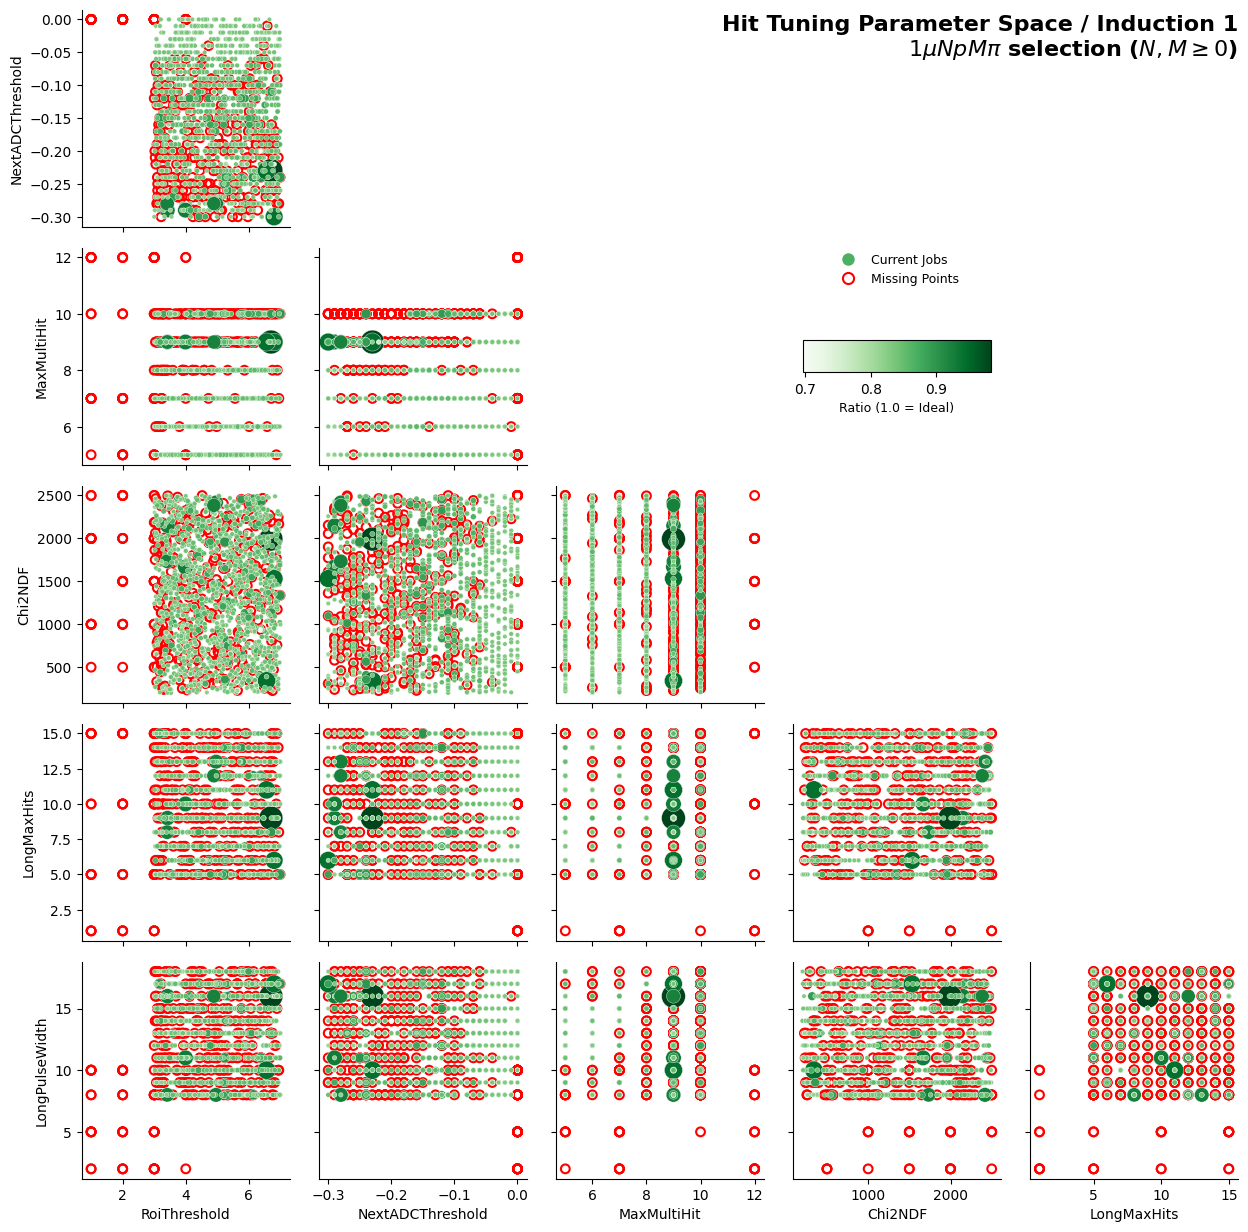

In [128]:
plot_corner(pd.read_pickle('dbs/pkl/merged1uNpMedian.pkl'), missing_bnb_points, 0, r'$1\mu Np M\pi$ selection ($N, M \geq 0$)')

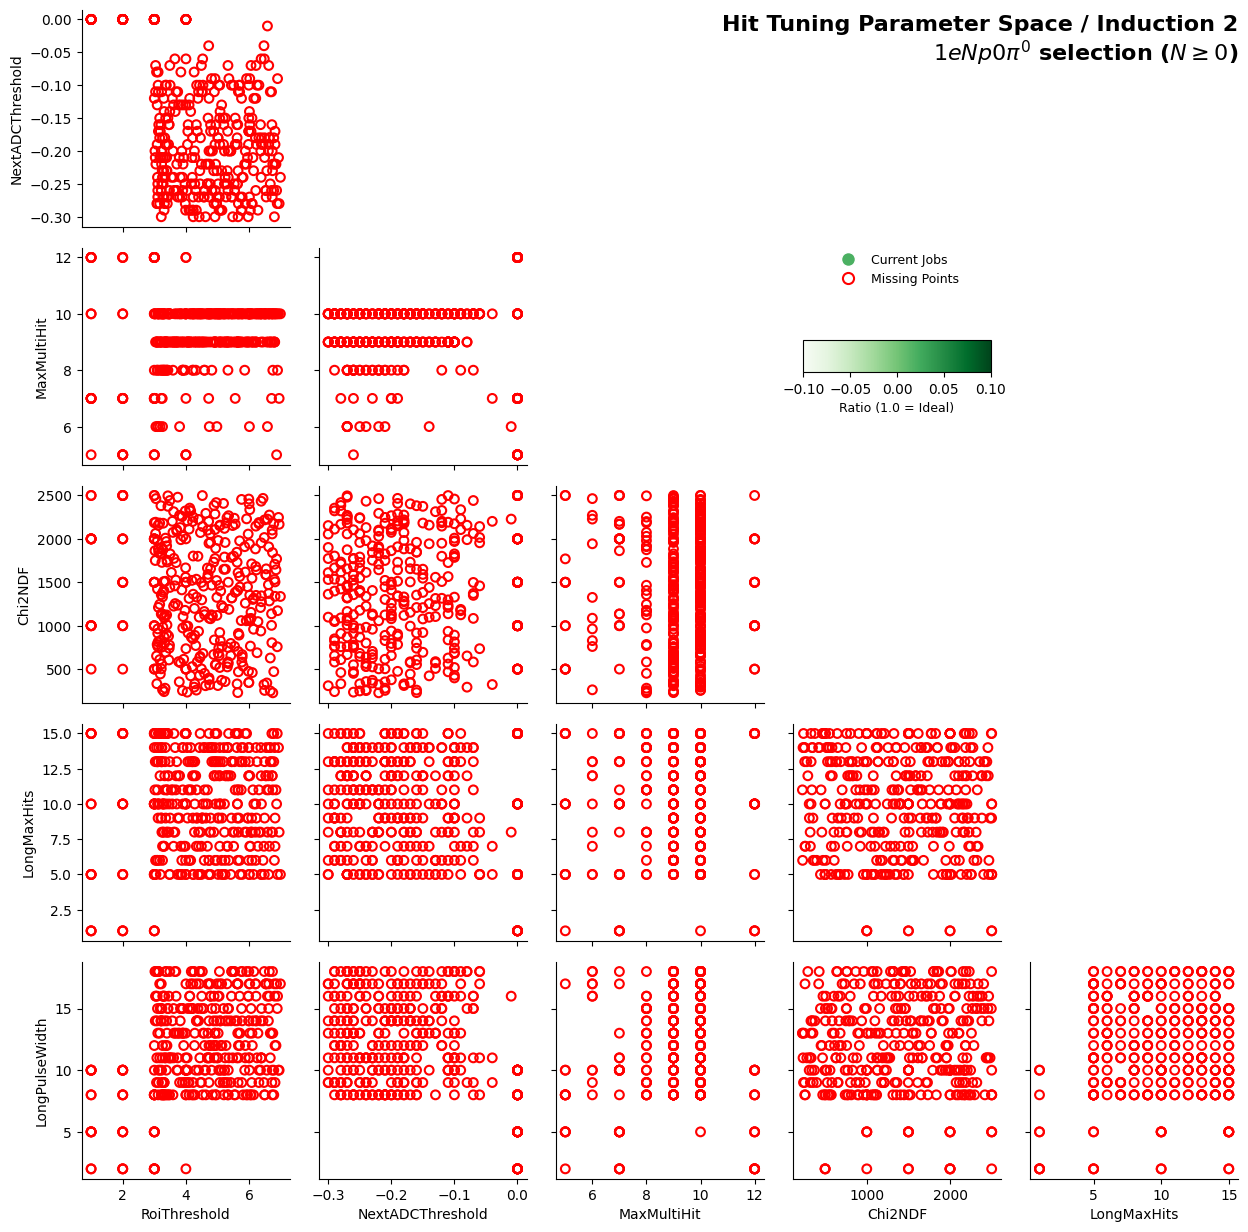

In [130]:
plot_corner(pd.read_pickle('dbs/pkl/merged1eNp0pi0Median.pkl'), missing_bnb_points, 1, r'$1e Np 0\pi^0$ selection ($N \geq 0$)')

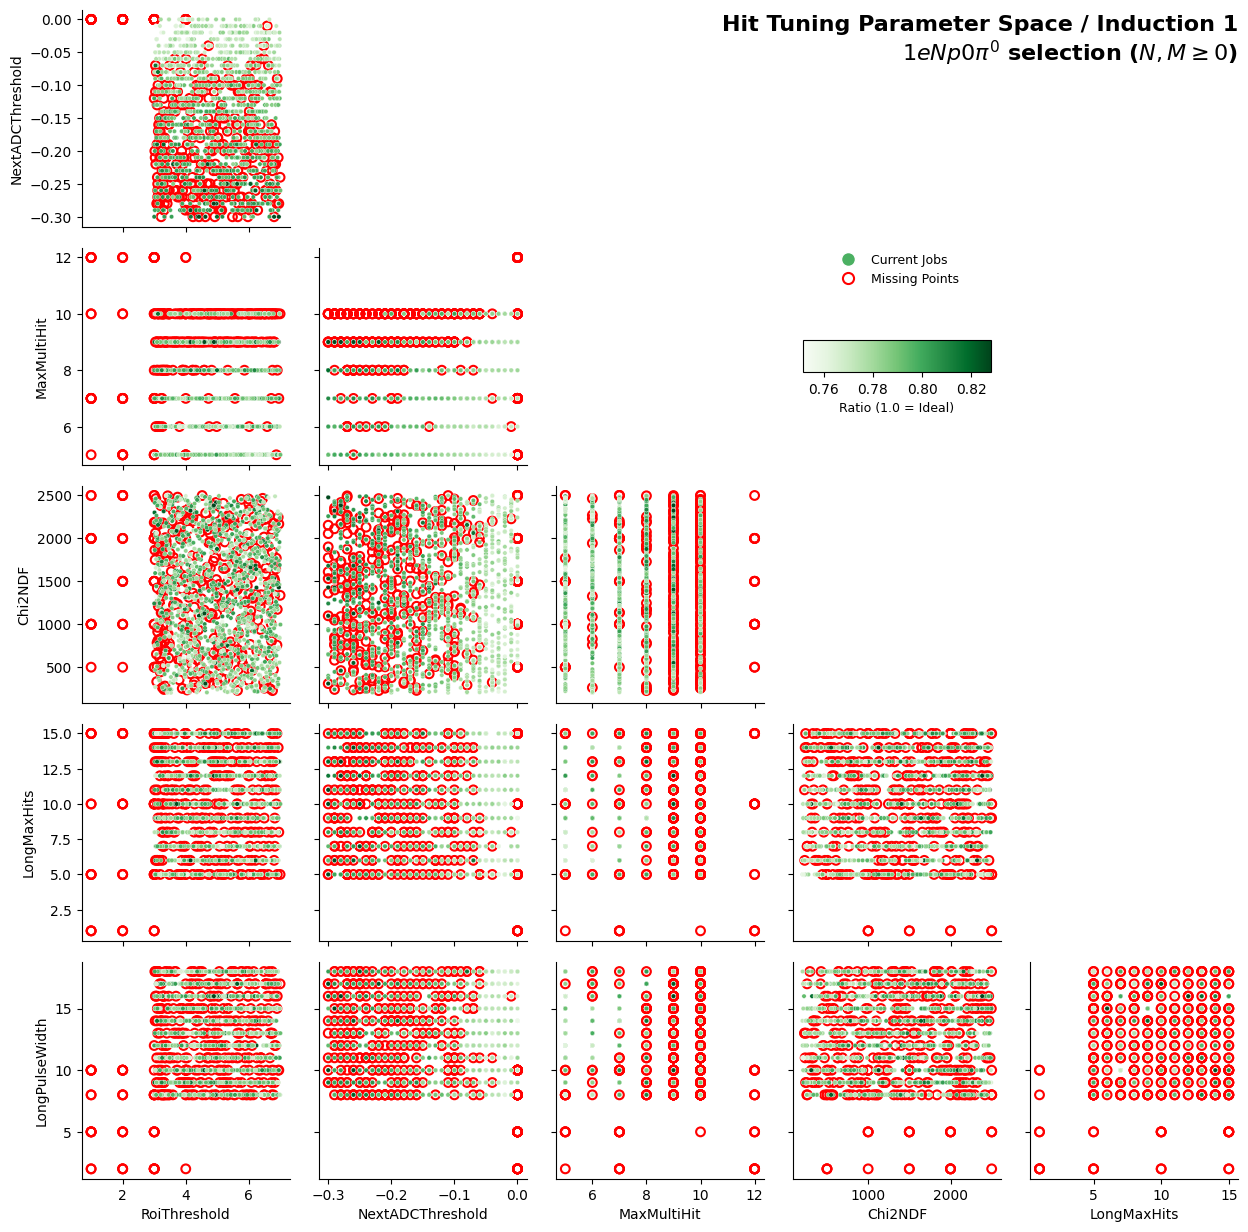

In [125]:
plot_corner(pd.read_pickle('dbs/pkl/merged1eNpMpi0Median.pkl'), missing_bnb_points, 0, r'$1e Np 0\pi^0$ selection ($N, M \geq 0$)')